In [1]:
# %% [markdown]
# # Local projections – ryddet version
# Delspørgsmål 1 (EUR/USD) og 3 (USD-hedge ratio) med SAMME LP-funktion.
# Åbn i VS Code: hver "# %%" er en celle, der kan køres som i en notebook.
# Rækkefølge: 0 imports → 1 data → 2 variable → 3 figurer (jeres egne) → 4 funktioner
#             → 5 lag-valg → 6 EUR/USD → 7 robusthed → 8 bootstrap → 9 hedge ratio

# %% 0) Imports  (installér statsmodels/matplotlib én gang i terminalen, ikke i notebooken)
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# %% 1) Indlæs masterdatasættet
BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
master = pd.read_csv(os.path.join(BASE, "clean", "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])
master = master.sort_values("month").reset_index(drop=True)

# %% 2) Variable
# Stød: log + standardisering (1 enhed = 1 standardafvigelse)
for v in ["TPU", "GPR", "GPRC_USA", "VIXCLS"]:
    master[f"ln{v}"] = np.log(master[v])
    master[f"ln{v}_z"] = (master[f"ln{v}"] - master[f"ln{v}"].mean()) / master[f"ln{v}"].std()

# Kontroller (stationære)
master["ip_growth"]  = np.log(master["INDPRO"]).diff()
master["nfp_growth"] = np.log(master["PAYEMS"]).diff()
master["d_DGS10"]    = master["DGS10"].diff()
# (inflation er allerede beregnet i databehandlingen)

# Outcome 1: dollarstyrke. + = dollaren styrkes over for euroen, i procent
master["lnUSD"]  = -100 * np.log(master["EURUSD"])
master["dlnUSD"] = master["lnUSD"].diff()

# Outcome 2: USD-hedge ratio i procentpoint + dens to komponenter (i log-pct.)
master["hr"]      = 100 * master["USD_hedge_ratio"]
master["ln_afd"]  = 100 * np.log(master["USD_afd_total"])    # afdækket beløb  (aktiv afdækning)
master["ln_eksp"] = 100 * np.log(master["USD_eksp_total"])   # samlet eksponering (værdiregulering)

# Ekstra kontrol og brud-dummies
master["d_ois_spread"] = (master["USD OIS 3m"] - master["EUR OIS 3m"]).diff()
master["post_LD"] = (master["month"] >= "2025-04-30").astype(int)   # Liberation Day
master["post_RU"] = (master["month"] >= "2022-02-28").astype(int)   # Ruslands invasion

# Persistens (deskriptivt, til teksten)
for v in ["lnTPU", "lnGPR", "lnGPRC_USA", "hr"]:
    tmp = master.assign(lag=master[v].shift(1)).dropna(subset=[v, "lag"])
    phi = smf.ols(f"{v} ~ lag", data=tmp).fit().params["lag"]
    print(f"{v}: phi = {phi:.3f}")



lnTPU: phi = 0.916
lnGPR: phi = 0.728
lnGPRC_USA: phi = 0.712
hr: phi = 0.917


In [2]:

# %% 3) Deskriptive figurer
# -> Behold jeres to hedge ratio-figurer og USD/EUR-begivenhedsfiguren uændret her.

# %% 4) FUNKTIONER
BASIS_KONTROLLER = ("ip_growth", "nfp_growth", "inflation", "d_DGS10")

#%% 4a) Lag-augmenteret long-difference local projection
def lp(data, y, shock, H=24, n_lags=1,
       controls=BASIS_KONTROLLER, extra_controls=(), samtidige=(),
       shock_lags=True, y_lags=True,
       slut=None, dummy=None, ekskluder=None,
       se="hc3", fast_stikproeve=False, niveau=False):
    """Lag-augmenteret long-difference local projection.
    Venstreside: y(t+h) - y(t-1)   (Jordà & Taylor 2025, lign. 12)
    Højreside:   stød(t) + lags 1..n_lags af stød, Δy og alle kontroller
                 (lag-augmentation, Montiel Olea & Plagborg-Møller 2021)
    se:      'hc3' (baseline), 'hc1' eller 'nw' (Newey-West, h lags)
    samtidige: variable der indgår SAMTIDIGT (kun bevidste 'bad control'-tjek)
    niveau:  True = lags af y i niveau i stedet for Δy (robusthed)"""
    d = data.sort_values("month").reset_index(drop=True).copy() # Måneder står i kronologisk rækkefølge, nummering af rækker efter sortering, laves i et kopi-datasæt, så master ikke ændres
    if slut is not None:                                   # Slut angiver slutningen for en periode
        d = d[d["month"] <= pd.Timestamp(slut)].reset_index(drop=True) 

    # extra_controls: laggede ekstra kontroller i robusthed (ændring i OIS-spændet USD–EUR, VIX)
    d["_dy"] = d[y].diff() # Laver delta y_t = y_t - y_{t-1}, dvs. dollarens bevægelse i den enkelte måned
    kilder = list(controls) + list(extra_controls) # De kontroller der skal lagges, i baseline er det kun controls
    if y_lags:
        kilder.append(y if niveau else "_dy")
    if shock_lags:
        kilder.append(shock)

    #Lags 
    lag_cols = []
    for v in kilder: 
        for L in range(1, n_lags + 1):
            d[f"{v}_L{L}"] = d[v].shift(L) 
            lag_cols.append(f"{v}_L{L}")

    X_cols = [shock] + list(samtidige) + lag_cols # Alle regressorer: stødet, fx lnTPU, dens koefficient der er impulsresponsen beta_h, lags fra ovenover
    if dummy is not None:
        d["_int"] = d[shock] * d[dummy] #Dummy kan være Post_LD altså efter liberation day. Altså lig 0 før og lig 1 efter.
        X_cols += [dummy, "_int"]

    # Stødmåneder der må indgå (fx ekskluder 2018-2019 for TPU og 2022-2023 for GPR) - robusthedstjek
    behold = pd.Series(True, index=d.index)                 
    if ekskluder is not None: # Sætter behold til False for de måneder der skal ekskluderes, fx 2018-2019 for TPU og 2022-2023 for GPR
        for a, b in ekskluder:
            behold &= ~d["month"].between(pd.Timestamp(a), pd.Timestamp(b)) # Timestamp(a) = 2018-01-31, Timestamp(b) = 2019-12-31. Dvs. behold = False for alle måneder mellem a og b
    if fast_stikproeve:
        behold &= d[y].shift(-H).notna()

    rows = []  # Liste til at gemme resultaterne for hvert horisont h, kører det hele for h = 0, 1, ..., H, dvs en regression per horisont h
    for h in range(H + 1):
        d["_lhs"] = d[y].shift(-h) - d[y].shift(1) # Venstreside: y(t+h) - y(t-1), dvs. dollarens bevægelse fra t-1 til t+h, altså h-måneders responsen på stødet
        sub = d.loc[behold, ["_lhs"] + X_cols].dropna() # datasættet til den enkelt regression, behold = True for de måneder der må indgå, dropna fjerner rækker med NaN. Derfor n falder med h, da der er færre måneder der kan indgå i regressionen for større h
        n_post = int(sub[dummy].sum()) if dummy is not None else None
        if dummy is not None and n_post < 3: # Hvis der er mindre end 3 observationer i post-perioden, så springes regressionen over, da det ikke giver mening at estimere en koefficient på dummy-interaktionen med så få observationer
            break
        mod = sm.OLS(sub["_lhs"], sm.add_constant(sub[X_cols])) # OLS regressionen, dvs. estimerer beta_h for hvert h, med konstantleddet (intercept)
        m = (mod.fit(cov_type="HAC", cov_kwds={"maxlags": h}) if se == "nw" # Newey-West standard errors, h lags
             else mod.fit(cov_type=se.upper())) # se = "hc3" for heteroskedasticity-robust standard errors
        r = {"h": h, "coef": m.params[shock], "se": m.bse[shock], 
             "p": m.pvalues[shock], "n": int(m.nobs)}
        if dummy is not None: # Hvis der er en dummy, skal vi også beregne effekten af stødet i post-perioden, dvs. effekten af stødet + effekten af interaktionen med dummy
            V = m.cov_params() 
            b_post = m.params[shock] + m.params["_int"] # Effekten af stødet i post-perioden = effekten af stødet i pre-perioden + effekten af interaktionen med dummy
            se_post = np.sqrt(V.loc[shock, shock] + V.loc["_int", "_int"] # standard error for effekten af stødet i post-perioden
                              + 2 * V.loc[shock, "_int"])
            r.update({"coef_int": m.params["_int"], "se_int": m.bse["_int"],
                      "p_int": m.pvalues["_int"],
                      "coef_post": b_post, "se_post": se_post,
                      "p_post": 2 * (1 - norm.cdf(abs(b_post / se_post))),
                      "n_post": n_post})
        rows.append(r) # hver horisont h får sin egen række i resultatet, med koefficienten, standard error, p-værdi og antal observationer
    return pd.DataFrame(rows)

# Samler resultaterne fra flere LP'er i en tabel, med koefficienter og p-værdier
def sammenlign(specs, horisonter=(0, 3, 6, 12, 18, 24), kol="coef", pkol="p"):
    """specs: {navn: resultat fra lp()} -> (tabel 'coef (p)', tabel med n)."""
    tab, nn = {}, {}
    for navn, res in specs.items():
        r = res.set_index("h").reindex(horisonter)
        tab[navn] = [f"{c:.2f} ({p:.3f})" if pd.notna(c) else "–"
                     for c, p in zip(r[kol], r[pkol])]
        nn[navn] = r["n"].tolist()
    return pd.DataFrame(tab, index=horisonter).T, pd.DataFrame(nn, index=horisonter).T

# Lag-valg: estimerer h=0-ligningen (som svarer til en VAR-ligning) med 1, ..., pmax lags
# og beregner AIC, HQ og BIC samt en Breusch-Godfrey-test for autokorrelation.
# Laveste informationskriterium = valgt antal lags (Jordà & Taylor 2025, s. 65).
# Alle modeller estimeres på samme stikprøve, så kriterierne kan sammenlignes.
def vaelg_lags(data, y, shock, pmax=6, controls=BASIS_KONTROLLER):
    """Informationskriterier på h=0-ligningen (Jordà & Taylor 2025, s. 65). Samme stikprøve for alle p."""
    d = data.sort_values("month").reset_index(drop=True).copy()
    d["_dy"] = d[y].diff()
    kilder = list(controls) + ["_dy", shock]
    for v in kilder:
        for L in range(1, pmax + 1):
            d[f"{v}_L{L}"] = d[v].shift(L)
    d["_lhs"] = d[y] - d[y].shift(1)
    alle = ["_lhs", shock] + [f"{v}_L{L}" for v in kilder for L in range(1, pmax + 1)]
    sub = d[alle].dropna()
    T, ud = len(sub), []
    for p in range(1, pmax + 1):
        X = sm.add_constant(sub[[shock] + [f"{v}_L{L}" for v in kilder for L in range(1, p + 1)]])
        m = sm.OLS(sub["_lhs"], X).fit()
        k = X.shape[1]
        ud.append({"p": p, "AIC": m.aic, "HQ": -2 * m.llf + 2 * k * np.log(np.log(T)),
                   "BIC": m.bic, "BG_p (12 lags)": acorr_breusch_godfrey(m, nlags=12)[1]})
    return pd.DataFrame(ud).set_index("p")




In [3]:
# ---------- Figur: før bruddet / efter bruddet ----------
z68, z95 = norm.ppf(0.84), norm.ppf(0.975)
BLAA, ROED = "#1f3864", "#b22222"


def tegn_panel(ax, h, b, se, farve, titel):
    ax.fill_between(h, b - z95 * se, b + z95 * se, color=farve, alpha=0.15, lw=0)
    ax.fill_between(h, b - z68 * se, b + z68 * se, color=farve, alpha=0.30, lw=0)
    ax.plot(h, b, color=farve, lw=2.5, marker="o", ms=3.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(titel, fontsize=12, pad=10)
    ax.set_xlabel("Måneder efter stødet (h)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)


def lp_figur_foer_efter(shock, filnavn, y="lnUSD",
                        ylabel="Pct. (+ = dollaren styrkes over for euroen)",
                        brud="post_LD", pre_slut="2024-12-31", post_slut=None,
                        titel_pre="Før 2025 (stikprøve til og med dec. 2024)",
                        titel_post="Efter Liberation Day (april 2025 →)",
                        H_pre=24, H_post=12, **lp_kw):
    res_pre  = lp(master, y, shock, H=H_pre,  slut=pre_slut, **lp_kw)
    res_post = lp(master, y, shock, H=H_post, dummy=brud, slut=post_slut, **lp_kw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
    tegn_panel(ax1, res_pre["h"], res_pre["coef"], res_pre["se"], BLAA, titel_pre)
    ax1.set_xticks(range(0, H_pre + 1, 3)); ax1.set_xlim(0, H_pre); ax1.set_ylabel(ylabel)

    if len(res_post) == 0:                                  # for få observationer efter bruddet
        ax2.text(0.5, 0.5, "For få observationer efter bruddet", ha="center",
                 transform=ax2.transAxes); ax2.set_axis_off()
    else:
        hp = res_post["h"]
        tegn_panel(ax2, hp, res_post["coef_post"], res_post["se_post"], ROED, titel_post)
        ax2.set_xlim(0, max(hp.max(), 1))
        trin = 2 if hp.max() <= 12 else 3
        vis = res_post[res_post["h"] % trin == 0]
        ax2.set_xticks(vis["h"])
        ax2.set_xticklabels([f"{h}\n(n={n})" for h, n in zip(vis["h"], vis["n_post"])], fontsize=9)
        faa = res_post.loc[res_post["n_post"] < 10, "h"]
        if len(faa) > 0:
            ax2.axvspan(faa.min() - 0.5, hp.max(), color="grey", alpha=0.10, lw=0)
            ax2.text(faa.min() - 0.3, ax2.get_ylim()[1], "Under 10 obs.", fontsize=9,
                     color="dimgray", va="top", ha="left")

    handles = [Line2D([0], [0], color="dimgray", lw=2.5, marker="o", ms=3.5, label="Impulsrespons"),
               Patch(facecolor="dimgray", alpha=0.30, label="68 pct. KI"),
               Patch(facecolor="dimgray", alpha=0.15, label="95 pct. KI")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/{filnavn}.pdf", bbox_inches="tight")
    plt.show()
    return res_pre, res_post




In [4]:
# ---------- Robusthedstabel (samme for EUR/USD og hedge ratio) ----------
VIX = "lnVIXCLS_z"
EPISODER_TPU_LP = [("2018-01-31", "2019-12-31"), ("2025-01-31", "2025-12-31")]
EPISODER_GPR_LP = [("2022-02-28", "2022-04-30"), ("2023-10-31", "2023-10-31"),
                   ("2025-03-31", "2025-06-30")]


def robusthed(y, s, episoder=None, se="hc3", H=24, n_lags=1, slut=None, dummy=None,
              kol="coef", pkol="p", horisonter=(0, 3, 6, 12, 18, 24), ekstra_specs=None):
    """Robusthedstabel: baseline + varianter, hvor én ting ændres ad gangen.
    slut=   : alle specifikationer på en kortere stikprøve (fx TPU før 2025)
    dummy=  : alle specifikationer med brud-dummy; vis da kol="coef_int", pkol="p_int"
    Rækken 'Newey-West' er baseline med NW-standardfejl (samme koefficienter, andre p-værdier)."""
    kw = dict(H=H, se=se, n_lags=n_lags, slut=slut, dummy=dummy)
    specs = {
        "Baseline":                 lp(master, y, s, **kw),
        "Newey-West-standardfejl":  lp(master, y, s, **{**kw, "se": "nw"}),
        f"{n_lags + 1} lags":       lp(master, y, s, **{**kw, "n_lags": n_lags + 1}),
        f"{n_lags + 2} lags":       lp(master, y, s, **{**kw, "n_lags": n_lags + 2}),
        "+ OIS-spænd (lagget)":     lp(master, y, s, **kw, extra_controls=("d_ois_spread",)),
        "+ VIX (lagget)":           lp(master, y, s, **kw, extra_controls=(VIX,)),
        "Niveauer i stedet for Δy": lp(master, y, s, **kw, niveau=True),
    }
    # Specifikationer, der kun giver mening uden brud-dummy
    if dummy is None:
        specs["Fast stikprøve"] = lp(master, y, s, **kw, fast_stikproeve=True)
        if episoder is not None:
            specs["Uden episoder"] = lp(master, y, s, **kw, ekskluder=episoder)
        if slut is None:
            specs["Til 2024"] = lp(master, y, s, **{**kw, "slut": "2024-12-31"})
    for navn, ekstra in (ekstra_specs or {}).items():
        specs[navn] = lp(master, y, s, **kw, **ekstra)

    hor = tuple(h for h in horisonter if h <= H)
    return sammenlign(specs, horisonter=hor, kol=kol, pkol=pkol)

In [5]:

# ---------- Bootstrap (Montiel Olea & Plagborg-Møller 2021, afsnit 5) ----------
def var_ols(Y, p): # Estimerer en VAR(p)-model med konstant ved OLS
    """VAR(p) med konstant ved OLS. Returnerer konstant c, liste af A_l og residualer U."""
    T, K = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l:T - l] for l in range(1, p + 1)])
    B = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    U = Y[p:] - X @ B
    return B[0], [B[1 + (l - 1) * K: 1 + l * K].T for l in range(1, p + 1)], U


def var_irf_kum(A, U, H, i_shock=0, i_y=-1):
    """VAR-implicit kumuleret respons (y_{t+h} - y_{t-1}), stødet ordnet først."""
    K, p = U.shape[1], len(A)
    S = U.T @ U / U.shape[0]
    b0 = S[:, i_shock] / S[i_shock, i_shock]
    Psi = [np.eye(K)]
    for j in range(1, H + 1):
        Psi.append(sum(A[i - 1] @ Psi[j - i] for i in range(1, min(j, p) + 1)))
    return np.cumsum([(Psi[j] @ b0)[i_y] for j in range(H + 1)])


def var_sim(c, A, U, Y0, rng):
    """Wild bootstrap: hver måneds residualvektor ganges med samme vægt ~ N(0,1)."""
    T_u, K = U.shape
    p = len(A)
    Ustar = U * rng.standard_normal(T_u)[:, None]
    Y = np.zeros((T_u + p, K))
    Y[:p] = Y0
    for t in range(p, T_u + p):
        Y[t] = c + sum(A[l - 1] @ Y[t - l] for l in range(1, p + 1)) + Ustar[t - p]
    return Y


def lp_bootstrap(data, shock, y="lnUSD", H=24, n_lags=1, controls=BASIS_KONTROLLER,
                 slut=None, B=999, seed=2026):
    """Percentile-t-bånd og bootstrap-p-værdi for lag-augmenteret LP."""
    res = lp(data, y, shock, H=H, n_lags=n_lags, controls=controls, slut=slut).copy()

    d = data.sort_values("month").reset_index(drop=True).copy()
    if slut is not None:
        d = d[d["month"] <= pd.Timestamp(slut)].reset_index(drop=True)
    d["dy"] = d[y].diff()
    kol = [shock] + list(controls) + ["dy"]
    d = d.dropna(subset=kol).reset_index(drop=True)
    Y = d[kol].to_numpy()
    c, A, U = var_ols(Y, n_lags)
    beta_var = var_irf_kum(A, U, H)

    rng = np.random.default_rng(seed)
    tstat = np.full((B, H + 1), np.nan)
    for b in range(B):
        start = rng.integers(0, len(Y) - n_lags + 1)          # tilfældig startblok (MOPM trin 4(ii))
        db = pd.DataFrame(var_sim(c, A, U, Y[start:start + n_lags], rng), columns=kol)
        db["month"] = d["month"].values
        db[y] = db["dy"].cumsum()                             # niveau genopbygges fra Δy
        rb = lp(db, y, shock, H=H, n_lags=n_lags, controls=controls)
        n = len(rb)
        tstat[b, :n] = (rb["coef"].values - beta_var[:n]) / rb["se"].values

    n = len(res)
    q = np.nanquantile(tstat[:, :n], [0.025, 0.16, 0.84, 0.975], axis=0)
    res["lo95"], res["hi95"] = res["coef"] - q[3] * res["se"], res["coef"] - q[0] * res["se"]
    res["lo68"], res["hi68"] = res["coef"] - q[2] * res["se"], res["coef"] - q[1] * res["se"]
    t_obs = (res["coef"] / res["se"]).values
    res["p_boot"] = np.nanmean(np.abs(tstat[:, :n]) >= np.abs(t_obs), axis=0)
    res["beta_var"] = beta_var[:n]
    return res



In [6]:

# %% 5) Lag-valg (EUR/USD)
#for s in ["lnTPU_z", "lnGPR_z", "lnGPRC_USA_z"]:
#    print(s); display(vaelg_lags(master, "lnUSD", s))



===== lnTPU_z | brud april 2025 =====


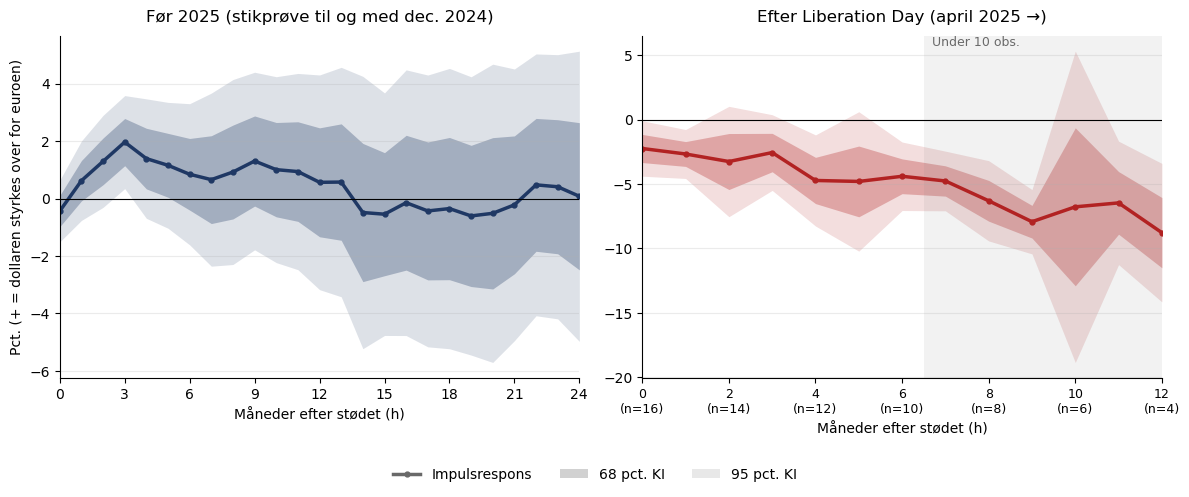

===== lnGPR_z | brud april 2025 =====


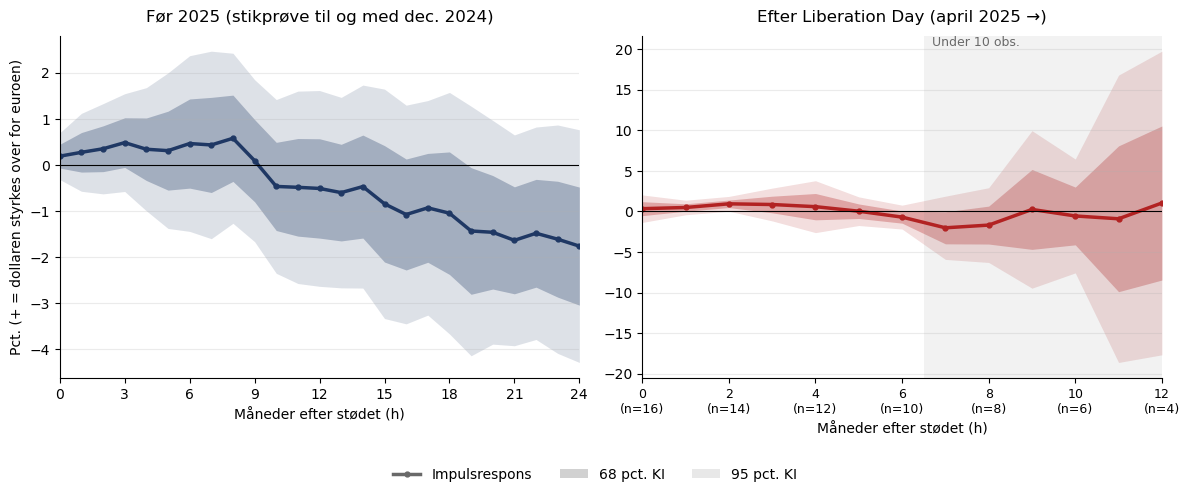

===== lnGPRC_USA_z | brud april 2025 =====


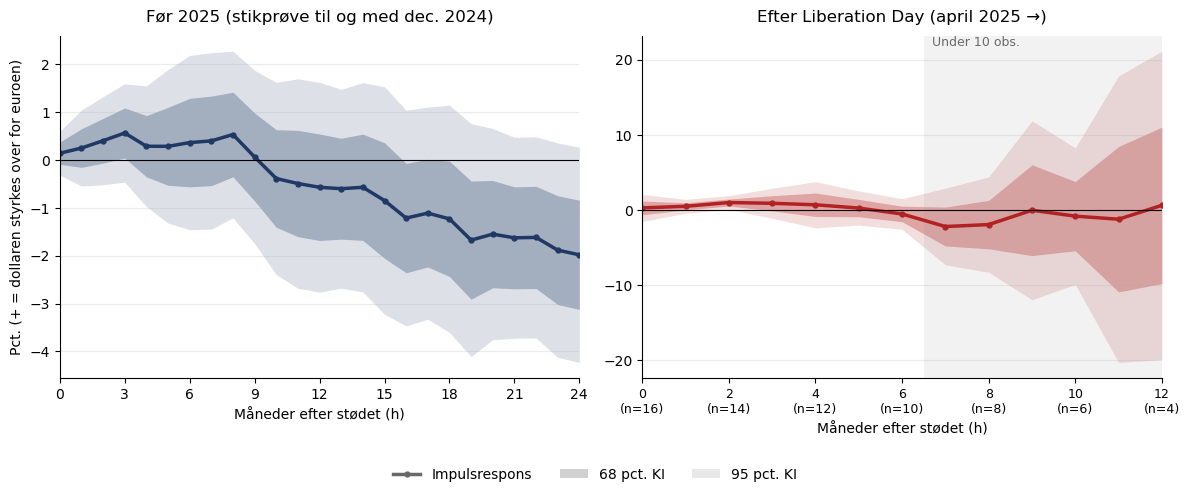

===== lnGPR_z | brud februar 2022 =====


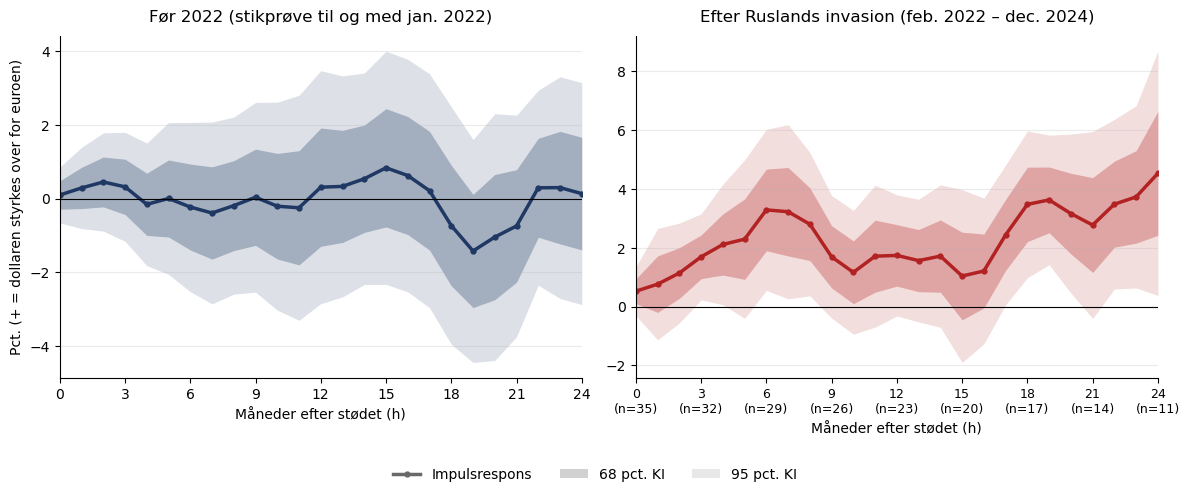

===== lnGPRC_USA_z | brud februar 2022 =====


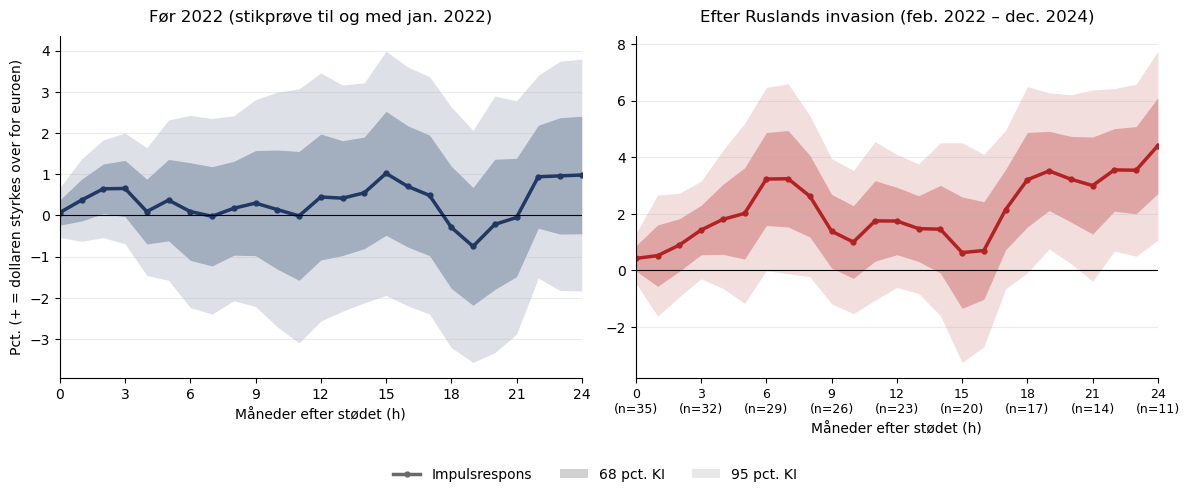

In [7]:
# %% 6) EUR/USD: før/efter-figurer
figurresultater = {}
for shock, fil in [("lnTPU_z",      "lp_tpu_foer_efter_hc3"),
                   ("lnGPR_z",      "lp_gpr_foer_efter_hc3"),
                   ("lnGPRC_USA_z", "lp_gpr_usa_foer_efter_hc3")]:
    print(f"===== {shock} | brud april 2025 =====")
    figurresultater[(shock, "2025")] = lp_figur_foer_efter(shock, fil)

for shock, fil in [("lnGPR_z",      "lp_gpr_foer_efter_2022_hc3"),
                   ("lnGPRC_USA_z", "lp_gpr_usa_foer_efter_2022_hc3")]:
    print(f"===== {shock} | brud februar 2022 =====")
    figurresultater[(shock, "2022")] = lp_figur_foer_efter(
        shock, fil, brud="post_RU", pre_slut="2022-01-31", post_slut="2024-12-31",
        titel_pre="Før 2022 (stikprøve til og med jan. 2022)",
        titel_post="Efter Ruslands invasion (feb. 2022 – dec. 2024)", H_post=24)



## Tabel-resultater for ovenstående

In [8]:
# %% 6b) Tabeller til før/efter-figurerne
def stjerner(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def vis_foer_efter(key, horisonter=None):
    pre, post = (r.copy() for r in figurresultater[key])
    if horisonter is not None:
        pre, post = pre[pre["h"].isin(horisonter)], post[post["h"].isin(horisonter)]

    pre["sig"] = pre["p"].apply(stjerner)
    print(f"\n===== {key[0]} | brud {key[1]} | VENSTRE PANEL: før bruddet =====")
    display(pre[["h", "coef", "se", "p", "sig", "n"]].round(3))

    if len(post) > 0:
        post["sig_post"] = post["p_post"].apply(stjerner)
        post["sig_int"]  = post["p_int"].apply(stjerner)
        print(f"===== {key[0]} | brud {key[1]} | HØJRE PANEL: efter bruddet + forskel =====")
        display(post[["h", "coef_post", "se_post", "p_post", "sig_post",
                      "coef_int", "p_int", "sig_int", "n_post"]].round(3))

#for key in figurresultater:
#    vis_foer_efter(key)

In [9]:
# %% 6c) LaTeX-tabeller til specialet
def _stj(p):
    return "^{***}" if p < 0.01 else "^{**}" if p < 0.05 else "^{*}" if p < 0.10 else ""

def _celle(df, h, b, se, p):
    if df is None or h not in df.index or pd.isna(df.loc[h, b]):
        return "–", ""
    return f"${df.loc[h, b]:.2f}{_stj(df.loc[h, p])}$", f"$({df.loc[h, se]:.2f})$"

NOTE_LP = (r"Koefficienter fra ligning \eqref{eq:lp_final} for et stød på én standardafvigelse "
           r"i det log-transformerede usikkerhedsindeks. Responsen er målt i pct. (+ = dollaren "
           r"styrkes over for euroen). HC3-standardfejl i parentes. (1) Hele stikprøven. "
           r"(2) Stikprøve til og med december 2024. (3) Responsen efter april 2025, "
           r"$\beta_h+\phi_h$, fra ligning \eqref{eq:lp_dummy}. (4) Interaktionsleddet $\phi_h$, "
           r"dvs. forskellen mellem perioderne. $n_{\text{post}}$ angiver antallet af "
           r"observationer efter bruddet; resultater baseret på færre end 10 observationer "
           r"bør tolkes med forsigtighed. $^{*}$, $^{**}$ og $^{***}$ angiver signifikans på "
           r"10, 5 og 1 pct.-niveau.")

def lp_tabel(key, titel, label, y="lnUSD", H_TAB=(0, 1, 2, 3, 4, 6, 9, 12),
             fuld_slut=None, kol_pre="Før 2025", kol_post="Efter april 2025", note=None):
    shock = key[0]
    pre, post = (r.set_index("h") for r in figurresultater[key])
    if len(post) == 0:
        post = None
    fuld = lp(master, y, shock, H=max(H_TAB), slut=fuld_slut).set_index("h")

    linjer = []
    for h in H_TAB:
        c1 = _celle(fuld, h, "coef", "se", "p")
        c2 = _celle(pre,  h, "coef", "se", "p")
        c3 = _celle(post, h, "coef_post", "se_post", "p_post")
        c4 = _celle(post, h, "coef_int", "se_int", "p_int")
        npost = int(post.loc[h, "n_post"]) if post is not None and h in post.index else "–"
        linjer.append(f"{h} & {c1[0]} & {c2[0]} & {c3[0]} & {c4[0]} & {npost} \\\\")
        linjer.append(f" & {c1[1]} & {c2[1]} & {c3[1]} & {c4[1]} & \\\\[2pt]")

    tex = (r"""\begin{table}[htbp]
\centering
\caption{""" + titel + r"""}
\label{""" + label + r"""}
\begin{threeparttable}
\begin{tabular}{l cccc c}
\toprule
 & (1) & (2) & (3) & (4) & \\
$h$ & Hele perioden & """ + kol_pre + " & " + kol_post + r""" & Forskel & $n_{\text{post}}$ \\
\midrule
""" + "\n".join(linjer) + r"""
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]\footnotesize
\item \textit{Note:} """ + (note or r"Se note til tabel \ref{tab:lp_tpu}.") + r"""
\end{tablenotes}
\end{threeparttable}
\end{table}""")

    os.makedirs("TABLES", exist_ok=True)
    fil = f"TABLES/{label.replace('tab:', '')}.tex"
    with open(fil, "w", encoding="utf-8") as f:
        f.write(tex)
    print(f"Gemt: {fil}")
    return tex

# Hovedtekst
print(lp_tabel(("lnTPU_z", "2025"),
               "Dollarens respons på et stød til handelspolitisk usikkerhed (TPU)",
               "tab:lp_tpu", note=NOTE_LP))

# Appendiks
lp_tabel(("lnGPR_z", "2025"),
         "Dollarens respons på et stød til geopolitisk risiko (GPR)", "tab:lp_gpr")
lp_tabel(("lnGPRC_USA_z", "2025"),
         r"Dollarens respons på et stød til geopolitisk risiko for USA ($\text{GPR}_{\text{USA}}$)",
         "tab:lp_gpr_usa")
lp_tabel(("lnGPR_z", "2022"),
         "Dollarens respons på et stød til geopolitisk risiko (GPR), brud i februar 2022",
         "tab:lp_gpr_2022", H_TAB=(0, 3, 6, 9, 12, 18, 24), fuld_slut="2024-12-31",
         kol_pre="Før 2022", kol_post="Efter feb. 2022",
         note=r"Som tabel \ref{tab:lp_tpu}, men med brud i februar 2022 og stikprøve til og "
              r"med december 2024. Kolonne (1) dækker hele perioden til og med december 2024.")

Gemt: TABLES/lp_tpu.tex
\begin{table}[htbp]
\centering
\caption{Dollarens respons på et stød til handelspolitisk usikkerhed (TPU)}
\label{tab:lp_tpu}
\begin{threeparttable}
\begin{tabular}{l cccc c}
\toprule
 & (1) & (2) & (3) & (4) & \\
$h$ & Hele perioden & Før 2025 & Efter april 2025 & Forskel & $n_{\text{post}}$ \\
\midrule
0 & $-0.71$ & $-0.44$ & $-2.25^{**}$ & $-1.70^{*}$ & 16 \\
 & $(0.55)$ & $(0.55)$ & $(1.10)$ & $(1.01)$ & \\[2pt]
1 & $-0.13$ & $0.62$ & $-2.67^{***}$ & $-2.81^{***}$ & 15 \\
 & $(0.76)$ & $(0.71)$ & $(0.97)$ & $(0.97)$ & \\[2pt]
2 & $0.20$ & $1.29$ & $-3.26$ & $-3.78^{*}$ & 14 \\
 & $(0.97)$ & $(0.82)$ & $(2.18)$ & $(2.08)$ & \\[2pt]
3 & $0.87$ & $1.97^{**}$ & $-2.56^{*}$ & $-3.71^{**}$ & 13 \\
 & $(0.94)$ & $(0.83)$ & $(1.50)$ & $(1.61)$ & \\[2pt]
4 & $0.37$ & $1.39$ & $-4.73^{***}$ & $-5.37^{***}$ & 12 \\
 & $(1.07)$ & $(1.06)$ & $(1.80)$ & $(1.89)$ & \\[2pt]
6 & $-0.25$ & $0.84$ & $-4.40^{***}$ & $-4.22^{***}$ & 10 \\
 & $(1.22)$ & $(1.25)$ & $(1.36)$ & $(1.

'\\begin{table}[htbp]\n\\centering\n\\caption{Dollarens respons på et stød til geopolitisk risiko (GPR), brud i februar 2022}\n\\label{tab:lp_gpr_2022}\n\\begin{threeparttable}\n\\begin{tabular}{l cccc c}\n\\toprule\n & (1) & (2) & (3) & (4) & \\\\\n$h$ & Hele perioden & Før 2022 & Efter feb. 2022 & Forskel & $n_{\\text{post}}$ \\\\\n\\midrule\n0 & $0.19$ & $0.10$ & $0.52$ & $0.46$ & 35 \\\\\n & $(0.26)$ & $(0.39)$ & $(0.42)$ & $(0.61)$ & \\\\[2pt]\n3 & $0.48$ & $0.32$ & $1.69^{**}$ & $1.51$ & 32 \\\\\n & $(0.54)$ & $(0.75)$ & $(0.75)$ & $(1.09)$ & \\\\[2pt]\n6 & $0.46$ & $-0.23$ & $3.29^{**}$ & $3.62^{**}$ & 29 \\\\\n & $(0.97)$ & $(1.17)$ & $(1.40)$ & $(1.78)$ & \\\\[2pt]\n9 & $0.09$ & $0.04$ & $1.69$ & $1.59$ & 26 \\\\\n & $(0.90)$ & $(1.31)$ & $(1.06)$ & $(1.52)$ & \\\\[2pt]\n12 & $-0.51$ & $0.31$ & $1.74^{*}$ & $2.61^{*}$ & 23 \\\\\n & $(1.08)$ & $(1.61)$ & $(1.05)$ & $(1.53)$ & \\\\[2pt]\n18 & $-1.05$ & $-0.73$ & $3.48^{***}$ & $5.74^{***}$ & 17 \\\\\n & $(1.34)$ & $(1.64)$ & $(1

# ROBUSTHEDSTESTS

In [10]:
# %% 7) EUR/USD: robusthed
# GPR og GPR_USA: hele perioden er hovedresultatet
for s in ["lnGPR_z", "lnGPRC_USA_z"]:
    koef, n = robusthed("lnUSD", s, EPISODER_GPR_LP)
    print(f"\n===== Robusthed | {s} | hele perioden ====="); display(koef)

# TPU (a): appreciering før 2025
koef, n = robusthed("lnUSD", "lnTPU_z", EPISODER_TPU_LP, slut="2024-12-31",
                    horisonter=(0, 1, 2, 3, 4, 6, 12, 24))
print("\n===== Robusthed | TPU | før 2025 ====="); display(koef)

# TPU (b): bruddet efter april 2025 (forskellen phi_h)
koef, n = robusthed("lnUSD", "lnTPU_z", H=12, dummy="post_LD",
                    kol="coef_int", pkol="p_int", horisonter=(0, 1, 2, 3, 4, 6, 9, 12))
print("\n===== Robusthed | TPU | forskel før/efter april 2025 ====="); display(koef)


===== Robusthed | lnGPR_z | hele perioden =====


,0,3,6,12,18,24
Baseline,0.08 (0.770),0.22 (0.671),0.01 (0.988),-0.91 (0.363),-1.45 (0.215),-1.97 (0.091)
Newey-West-standardfejl,0.08 (0.742),0.22 (0.628),0.01 (0.987),-0.91 (0.220),-1.45 (0.049),-1.97 (0.011)
2 lags,0.03 (0.928),0.27 (0.622),0.03 (0.974),-0.83 (0.396),-1.08 (0.352),-1.60 (0.166)
3 lags,0.01 (0.986),0.27 (0.637),0.06 (0.946),-0.90 (0.331),-1.37 (0.235),-1.74 (0.129)
+ OIS-spænd (lagget),0.08 (0.771),0.20 (0.691),-0.01 (0.992),-1.02 (0.306),-1.49 (0.197),-1.97 (0.095)
+ VIX (lagget),0.08 (0.771),0.22 (0.676),-0.00 (0.998),-0.91 (0.367),-1.38 (0.229),-1.86 (0.086)
Niveauer i stedet for Δy,0.14 (0.575),0.43 (0.236),0.63 (0.360),0.37 (0.565),-0.20 (0.749),-0.94 (0.189)
Fast stikprøve,0.24 (0.340),0.40 (0.482),0.42 (0.668),-0.35 (0.740),-1.23 (0.300),-1.97 (0.091)
Uden episoder,0.29 (0.279),0.50 (0.309),-0.54 (0.529),-1.55 (0.226),-2.27 (0.039),-3.06 (0.002)
Til 2024,0.19 (0.466),0.48 (0.372),0.46 (0.634),-0.51 (0.637),-1.05 (0.433),-1.76 (0.171)



===== Robusthed | lnGPRC_USA_z | hele perioden =====


,0,3,6,12,18,24
Baseline,0.03 (0.917),0.25 (0.607),-0.10 (0.902),-1.01 (0.317),-1.65 (0.126),-2.13 (0.042)
Newey-West-standardfejl,0.03 (0.907),0.25 (0.562),-0.10 (0.890),-1.01 (0.193),-1.65 (0.012),-2.13 (0.008)
2 lags,-0.05 (0.869),0.35 (0.522),-0.09 (0.923),-0.87 (0.387),-1.23 (0.275),-1.71 (0.120)
3 lags,-0.03 (0.915),0.41 (0.485),0.07 (0.936),-0.73 (0.459),-1.26 (0.272),-1.61 (0.148)
+ OIS-spænd (lagget),0.03 (0.917),0.25 (0.618),-0.12 (0.888),-1.12 (0.269),-1.69 (0.111),-2.13 (0.044)
+ VIX (lagget),0.02 (0.926),0.25 (0.620),-0.14 (0.875),-1.01 (0.320),-1.57 (0.142),-1.97 (0.045)
Niveauer i stedet for Δy,0.07 (0.757),0.43 (0.239),0.44 (0.523),0.21 (0.754),-0.40 (0.525),-1.07 (0.131)
Fast stikprøve,0.17 (0.456),0.49 (0.363),0.32 (0.733),-0.45 (0.677),-1.42 (0.192),-2.13 (0.042)
Uden episoder,0.22 (0.369),0.56 (0.240),-0.43 (0.626),-1.46 (0.239),-2.17 (0.040),-2.81 (0.004)
Til 2024,0.14 (0.545),0.56 (0.283),0.36 (0.696),-0.57 (0.610),-1.23 (0.310),-1.98 (0.084)



===== Robusthed | TPU | før 2025 =====


,0,1,2,3,4,6,12,24
Baseline,-0.44 (0.427),0.62 (0.379),1.29 (0.113),1.97 (0.017),1.39 (0.190),0.84 (0.501),0.56 (0.767),0.08 (0.976)
Newey-West-standardfejl,-0.44 (0.391),0.62 (0.338),1.29 (0.059),1.97 (0.004),1.39 (0.155),0.84 (0.419),0.56 (0.708),0.08 (0.960)
2 lags,-0.22 (0.698),0.84 (0.266),1.91 (0.021),2.55 (0.004),2.08 (0.085),1.39 (0.303),1.09 (0.605),-0.03 (0.987)
3 lags,-0.26 (0.655),0.85 (0.256),1.93 (0.021),2.55 (0.008),2.09 (0.098),1.42 (0.335),1.06 (0.636),0.65 (0.759)
+ OIS-spænd (lagget),-0.47 (0.398),0.57 (0.429),1.17 (0.169),1.73 (0.043),1.12 (0.312),0.69 (0.600),0.36 (0.854),0.28 (0.908)
+ VIX (lagget),-0.44 (0.423),0.61 (0.392),1.29 (0.122),1.94 (0.021),1.35 (0.217),0.77 (0.553),0.57 (0.769),0.23 (0.921)
Niveauer i stedet for Δy,-0.53 (0.338),0.44 (0.514),0.97 (0.115),1.57 (0.023),0.82 (0.329),-0.02 (0.977),-1.08 (0.264),-1.89 (0.085)
Fast stikprøve,-0.89 (0.163),0.25 (0.772),1.09 (0.265),1.88 (0.053),1.28 (0.299),1.05 (0.481),0.60 (0.783),0.08 (0.976)
Uden episoder,-0.04 (0.958),0.94 (0.403),1.25 (0.260),1.38 (0.289),0.04 (0.979),-1.68 (0.281),-3.42 (0.116),0.03 (0.994)



===== Robusthed | TPU | forskel før/efter april 2025 =====


,0,1,2,3,4,6,9,12
Baseline,-1.70 (0.092),-2.81 (0.004),-3.78 (0.069),-3.71 (0.021),-5.37 (0.004),-4.22 (0.004),-7.66 (0.000),-7.92 (0.014)
Newey-West-standardfejl,-1.70 (0.030),-2.81 (0.000),-3.78 (0.000),-3.71 (0.000),-5.37 (0.000),-4.22 (0.001),-7.66 (0.000),-7.92 (0.000)
2 lags,-2.05 (0.054),-3.25 (0.004),-4.91 (0.031),-4.68 (0.005),-6.31 (0.007),-5.32 (0.039),-10.03 (0.000),-11.71 (0.023)
3 lags,-1.96 (0.089),-3.62 (0.004),-5.01 (0.036),-4.72 (0.010),-6.14 (0.024),-5.34 (0.066),-10.81 (0.005),-11.08 (0.150)
+ OIS-spænd (lagget),-1.75 (0.086),-2.88 (0.006),-4.07 (0.056),-4.39 (0.012),-6.28 (0.002),-5.03 (0.002),-8.88 (0.000),-8.40 (0.005)
+ VIX (lagget),-1.67 (0.098),-2.74 (0.003),-3.74 (0.070),-3.64 (0.021),-5.17 (0.008),-3.76 (0.021),-7.01 (0.004),-7.93 (0.017)
Niveauer i stedet for Δy,-1.39 (0.102),-2.07 (0.015),-2.53 (0.070),-1.95 (0.068),-2.71 (0.004),-0.80 (0.691),-1.03 (0.709),0.27 (0.952)


## TABELLER TIL ROBUSTHEDSTESTS

In [17]:
def robust_tex(koef, titel, label, note):
    """Laver en robusthedstabel (koefficient med stjerner) ud fra robusthed()-output."""
    def fmt(celle):
        if celle == "–":
            return "–"
        c, p = celle.split(" (")
        return f"${float(c):.2f}{_stj(float(p.rstrip(')')))}$"
    hor = list(koef.columns)
    linjer = [navn.replace("Δy", r"$\Delta y$") + " & " + " & ".join(fmt(x) for x in raekke) + r" \\"
              for navn, raekke in koef.iterrows()]
    tex = (r"""\begin{table}[htbp]
\centering
\caption{""" + titel + r"""}
\label{""" + label + r"""}
\begin{threeparttable}
\begin{tabular}{l""" + "c" * len(hor) + r"""}
\toprule
 & \multicolumn{""" + str(len(hor)) + r"""}{c}{Horisont $h$} \\
\cmidrule(lr){2-""" + str(len(hor) + 1) + r"""}
Specifikation & """ + " & ".join(str(h) for h in hor) + r""" \\
\midrule
""" + "\n".join(linjer) + r"""
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]\footnotesize
\item \textit{Note:} """ + note + r"""
\end{tablenotes}
\end{threeparttable}
\end{table}""")
    os.makedirs("TABLES", exist_ok=True)
    with open(f"TABLES/{label.replace('tab:', '')}.tex", "w", encoding="utf-8") as f:
        f.write(tex)
    print(f"Gemt: TABLES/{label.replace('tab:', '')}.tex")


NOTE_ROB = (r"Responsen i pct. (+ = dollaren styrkes over for euroen) på et stød på én "
            r"standardafvigelse. Hver række ændrer én ting i forhold til baseline-specifikationen "
            r"i ligning \eqref{eq:lp_final}. Stjerner angiver signifikans baseret på "
            r"HC3-standardfejl, bortset fra rækken med Newey-West-standardfejl. "
            r"$^{*}$, $^{**}$ og $^{***}$ angiver signifikans på 10, 5 og 1 pct.-niveau.")

# GPR og GPR_USA: hele perioden
for s, navn, kort in [("lnGPR_z", "GPR", "gpr"),
                      ("lnGPRC_USA_z", r"$\text{GPR}_{\text{USA}}$", "gpr_usa")]:
    koef, _ = robusthed("lnUSD", s, EPISODER_GPR_LP)
    robust_tex(koef, f"Robusthed: dollarens respons på et {navn}-stød", f"tab:rob_{kort}",
               NOTE_ROB if kort == "gpr" else r"Se note til tabel \ref{tab:rob_gpr}.")

# TPU før 2025
koef, _ = robusthed("lnUSD", "lnTPU_z", EPISODER_TPU_LP, slut="2024-12-31",
                    horisonter=(0, 1, 2, 3, 4, 6, 12, 24))
robust_tex(koef, "Robusthed: dollarens respons på et TPU-stød før 2025", "tab:rob_tpu_foer",
           r"Som tabel \ref{tab:rob_gpr}, men alle specifikationer er estimeret på stikprøven til "
           r"og med december 2024. Episodeudeladelsen omfatter dermed kun handelskrigen 2018--2019.")

# TPU-bruddet
koef, _ = robusthed("lnUSD", "lnTPU_z", H=12, dummy="post_LD", kol="coef_int", pkol="p_int",
                    horisonter=(0, 1, 2, 3, 4, 6, 9, 12))
robust_tex(koef, "Robusthed: forskellen i dollarens respons på et TPU-stød før og efter april 2025",
           "tab:rob_tpu_brud",
           r"Koefficienten på interaktionsleddet $\phi_h$ i ligning \eqref{eq:lp_dummy}, dvs. "
           r"forskellen mellem responsen efter og før april 2025. Øvrige forhold som i note til "
           r"tabel \ref{tab:rob_gpr}.")

Gemt: TABLES/rob_gpr.tex
Gemt: TABLES/rob_gpr_usa.tex
Gemt: TABLES/rob_tpu_foer.tex
Gemt: TABLES/rob_tpu_brud.tex


In [24]:
# %% 8) EUR/USD: bootstrap (Montiel Olea & Plagborg-Møller 2021, afsnit 5)
#      Standard: B=999, n_lags=1. Test først hurtigt med B=99 i kaldene.
bs = {
    "TPU (før 2025)":            lp_bootstrap(master, "lnTPU_z", slut="2024-12-31"),
    "GPR":                       lp_bootstrap(master, "lnGPR_z"),
    r"$\text{GPR}_{\text{USA}}$": lp_bootstrap(master, "lnGPRC_USA_z"),
}
HOR_BS = (0, 1, 2, 3, 4, 6, 12, 18, 24)

# Se tallene i notebooken
for navn, r in bs.items():
    print(f"\n===== Bootstrap | {navn} =====")
    display(r.loc[r["h"].isin(HOR_BS), ["h", "coef", "p", "p_boot", "lo95", "hi95", "beta_var"]].round(3))

# LaTeX-tabel
linjer = []
for i, (navn, r) in enumerate(bs.items()):
    r = r.set_index("h")
    linjer.append(rf"\multicolumn{{5}}{{l}}{{\textit{{Panel {'ABC'[i]}: {navn}}}}} \\")
    for h in HOR_BS:
        if h in r.index:
            linjer.append(f"{h} & ${r.loc[h, 'coef']:.2f}$ & ${r.loc[h, 'p']:.3f}$ & "
                          f"${r.loc[h, 'p_boot']:.3f}$ & "
                          f"$[{r.loc[h, 'lo95']:.2f};\\ {r.loc[h, 'hi95']:.2f}]$ \\\\")
    linjer.append(r"\addlinespace")

tex = (r"""\begin{table}[htbp]
\centering
\caption{Bootstrap-baseret inferens}
\label{tab:bootstrap}
\begin{threeparttable}
\begin{tabular}{c cccc}
\toprule
$h$ & Koefficient & $p$ (HC3) & $p$ (bootstrap) & 95 pct. bootstrap-KI \\
\midrule
""" + "\n".join(linjer[:-1]) + r"""
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]\footnotesize
\item \textit{Note:} Responsen i pct. (+ = dollaren styrkes over for euroen) på et stød på
én standardafvigelse, estimeret med ligning \eqref{eq:lp_final}. Bootstrap-p-værdier og
percentile-t-konfidensintervaller er baseret på 999 wild bootstrap-replikationer fra den
tilsvarende VAR(1), jf. Montiel Olea og Plagborg-Møller (2021, afsnit 5). TPU er estimeret
på stikprøven til og med december 2024.
\end{tablenotes}
\end{threeparttable}
\end{table}""")

os.makedirs("TABLES", exist_ok=True)
with open("TABLES/bootstrap.tex", "w", encoding="utf-8") as f:
    f.write(tex)
print("Gemt: TABLES/bootstrap.tex")


===== Bootstrap | TPU (før 2025) =====


,h,coef,p,p_boot,lo95,hi95,beta_var
0,0,-0.436,0.427,0.332,-1.321,0.429,-0.436
1,1,0.621,0.379,0.332,-0.714,1.896,0.054
2,2,1.295,0.113,0.103,-0.054,2.963,0.482
3,3,1.966,0.017,0.033,0.444,3.903,0.809
4,4,1.391,0.190,0.189,-0.621,3.781,1.050
6,6,0.844,0.501,0.471,-1.362,3.641,1.374
12,12,0.565,0.767,0.775,-2.821,5.319,1.817
18,18,-0.350,0.888,0.893,-4.901,6.225,1.966
24,24,0.078,0.976,0.981,-4.981,7.894,2.019



===== Bootstrap | GPR =====


,h,coef,p,p_boot,lo95,hi95,beta_var
0,0,0.079,0.770,0.735,-0.365,0.461,0.079
1,1,-0.009,0.979,0.973,-0.646,0.565,0.104
2,2,0.129,0.750,0.710,-0.655,0.825,0.075
3,3,0.216,0.671,0.642,-0.758,1.178,0.071
4,4,0.059,0.918,0.911,-1.005,1.109,0.074
6,6,0.013,0.988,0.985,-1.694,1.926,0.096
12,12,-0.907,0.363,0.379,-2.862,1.160,0.137
18,18,-1.451,0.215,0.259,-4.165,0.828,0.145
24,24,-1.969,0.091,0.121,-4.760,0.437,0.147



===== Bootstrap | $\text{GPR}_{\text{USA}}$ =====


,h,coef,p,p_boot,lo95,hi95,beta_var
0,0,0.027,0.917,0.899,-0.379,0.409,0.027
1,1,-0.040,0.907,0.880,-0.673,0.518,0.061
2,2,0.153,0.703,0.682,-0.618,0.815,0.036
3,3,0.253,0.607,0.581,-0.657,1.143,0.030
4,4,-0.002,0.997,0.999,-1.031,1.047,0.032
6,6,-0.104,0.902,0.914,-1.691,1.625,0.051
12,12,-1.010,0.317,0.335,-2.931,1.145,0.087
18,18,-1.645,0.126,0.167,-4.139,0.598,0.094
24,24,-2.125,0.042,0.071,-4.545,0.099,0.095


Gemt: TABLES/bootstrap.tex


## HEDGE RATIO LP

Hedge ratio: 2015-01-31 til 2026-07-31 (139 mdr.) | mdr. efter april 2025: 16
===== Hedge ratio | hele perioden =====


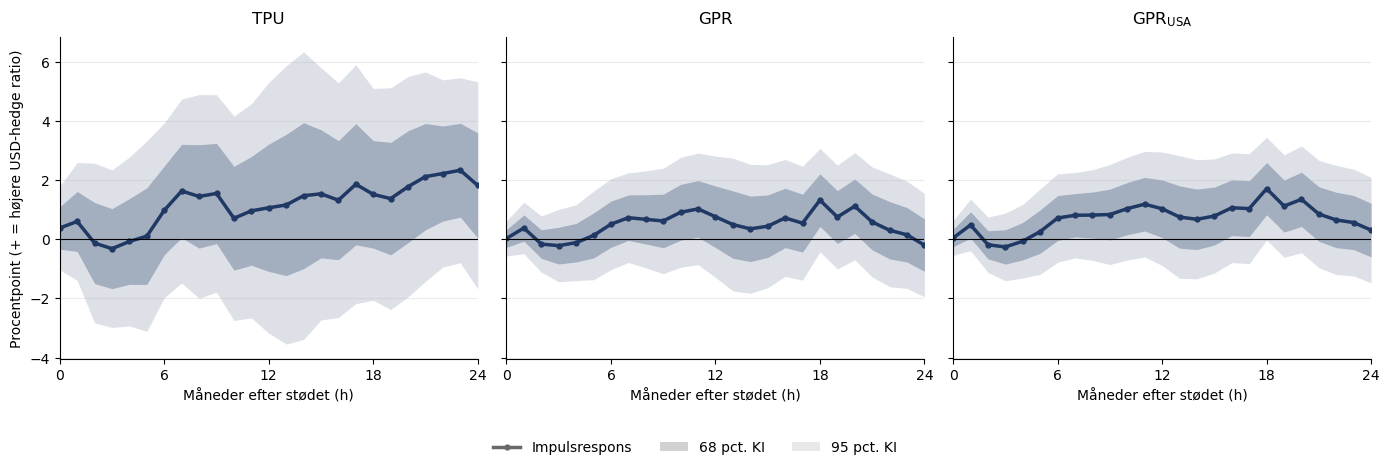

===== Hedge ratio | lnTPU_z | brud april 2025 =====


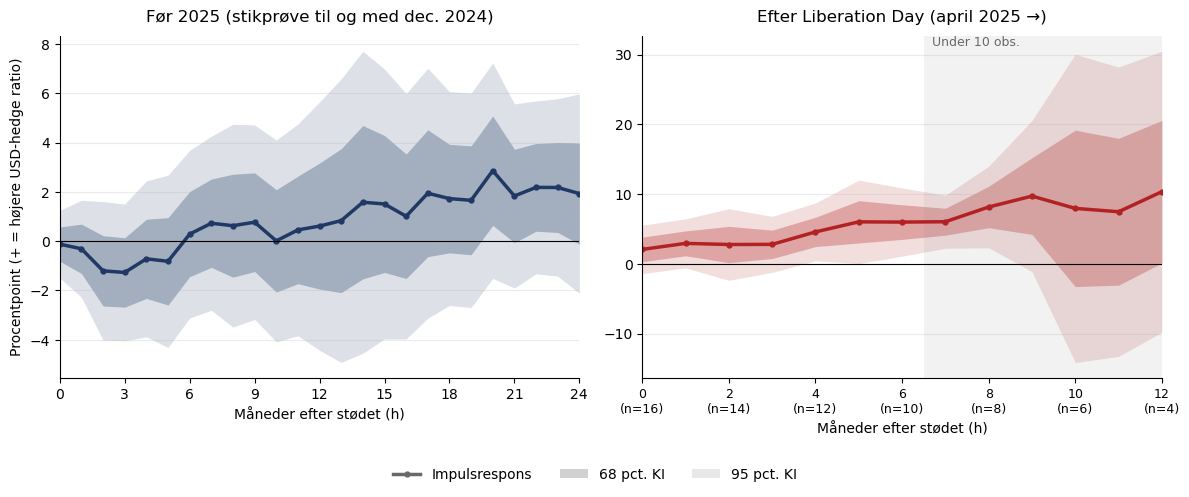

===== Hedge ratio | lnGPR_z | brud april 2025 =====


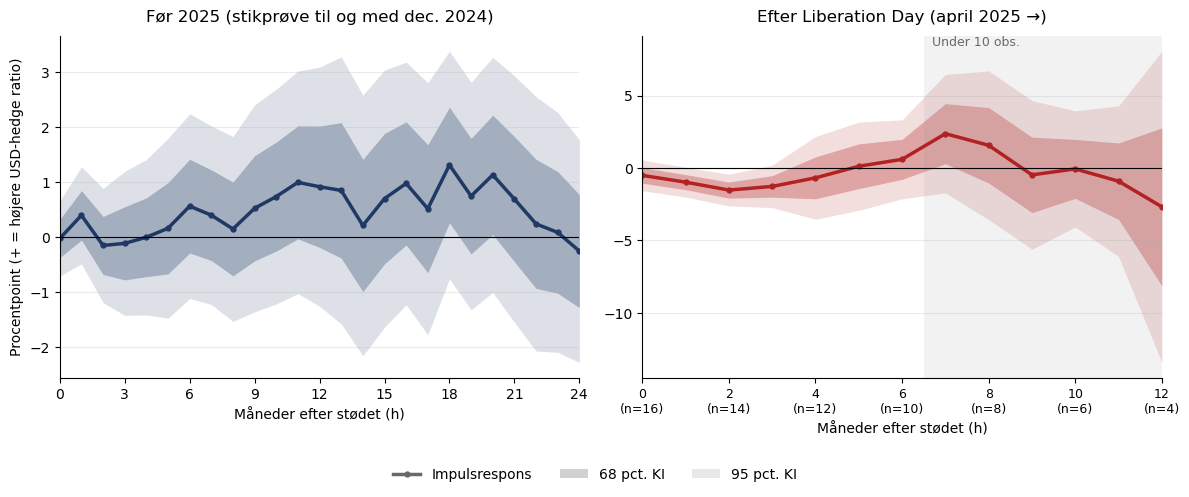

===== Hedge ratio | lnGPRC_USA_z | brud april 2025 =====


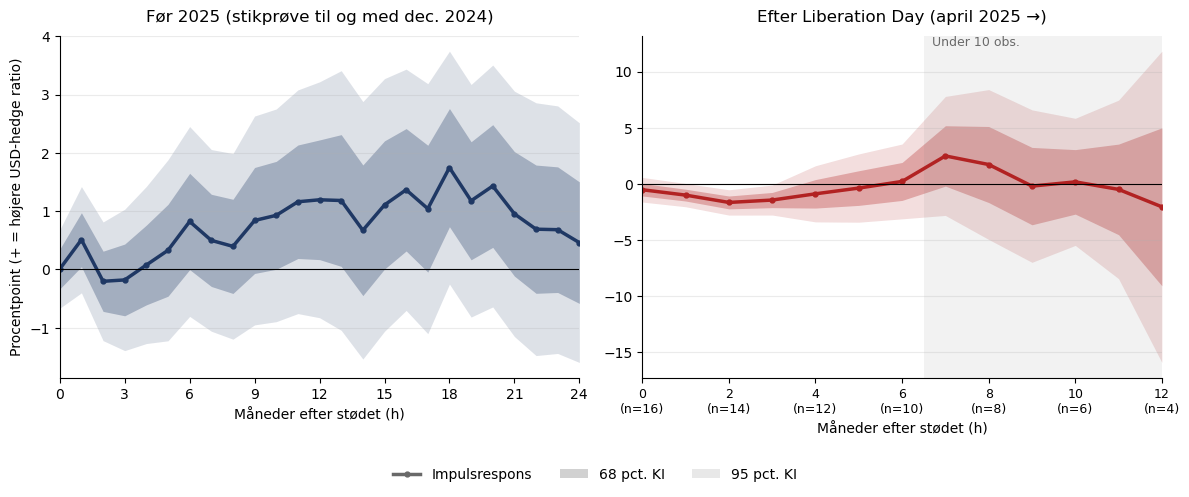


===== Hedge ratio | lnTPU_z | VENSTRE PANEL: før 2025 =====


,h,coef,se,p,sig,n
0,0,-0.121,0.698,0.863,,118
1,1,-0.310,1.005,0.758,,117
2,2,-1.204,1.432,0.401,,116
3,3,-1.270,1.415,0.370,,115
4,4,-0.716,1.614,0.657,,114
5,5,-0.818,1.783,0.646,,113
6,6,0.285,1.735,0.869,,112
7,7,0.727,1.801,0.687,,111
8,8,0.627,2.099,0.765,,110
9,9,0.770,2.012,0.702,,109


===== Hedge ratio | lnTPU_z | HØJRE PANEL: efter april 2025 + forskel =====


,h,coef_post,se_post,p_post,sig_post,coef_int,p_int,sig_int,n_post
0,0,2.082,1.772,0.240,,1.848,0.241,,16
1,1,2.945,1.790,0.100,*,2.515,0.131,,15
2,2,2.782,2.616,0.288,,3.055,0.205,,14
3,3,2.804,2.045,0.170,,3.231,0.110,,13
4,4,4.588,2.114,0.030,**,4.693,0.023,**,12
5,5,6.030,3.047,0.048,**,5.840,0.049,**,11
6,6,5.996,2.494,0.016,**,4.825,0.049,**,10
7,7,6.045,1.938,0.002,***,4.306,0.023,**,9
8,8,8.155,2.979,0.006,***,6.656,0.029,**,8
9,9,9.718,5.522,0.078,*,8.041,0.148,,7



===== Hedge ratio | lnGPR_z | VENSTRE PANEL: før 2025 =====


...

,0,3,6,12,18,24
Baseline,0.03 (0.933),-0.22 (0.727),0.51 (0.517),0.76 (0.468),1.32 (0.138),-0.20 (0.821)
Newey-West-standardfejl,0.03 (0.925),-0.22 (0.641),0.51 (0.359),0.76 (0.384),1.32 (0.005),-0.20 (0.784)
2 lags,0.14 (0.651),-0.36 (0.566),0.49 (0.552),0.66 (0.529),0.99 (0.291),-0.53 (0.558)
3 lags,0.15 (0.639),-0.39 (0.538),0.36 (0.660),0.56 (0.577),0.96 (0.353),-0.52 (0.589)
+ OIS-spænd (lagget),0.03 (0.924),-0.20 (0.752),0.51 (0.521),0.73 (0.485),1.27 (0.164),-0.22 (0.807)
+ VIX (lagget),0.03 (0.933),-0.22 (0.730),0.52 (0.512),0.75 (0.475),1.31 (0.146),-0.24 (0.789)
Niveauer i stedet for Δy,-0.08 (0.768),-0.53 (0.334),0.02 (0.982),-0.26 (0.732),0.54 (0.359),-0.62 (0.342)
Fast stikprøve,-0.05 (0.883),-0.01 (0.986),0.60 (0.483),0.63 (0.575),1.21 (0.187),-0.20 (0.821)
Uden episoder,-0.12 (0.718),-0.42 (0.566),0.87 (0.376),1.16 (0.399),1.14 (0.341),-0.49 (0.690)
Til 2024,-0.02 (0.946),-0.11 (0.867),0.56 (0.510),0.92 (0.408),1.31 (0.214),-0.25 (0.806)


,0,3,6,12,18,24
Baseline,137,134,131,125,119,113
Newey-West-standardfejl,137,134,131,125,119,113
2 lags,136,133,130,124,118,112
3 lags,135,132,129,123,117,111
+ OIS-spænd (lagget),137,134,131,125,119,113
+ VIX (lagget),137,134,131,125,119,113
Niveauer i stedet for Δy,137,134,131,125,119,113
Fast stikprøve,113,113,113,113,113,113
Uden episoder,129,126,123,117,115,109
Til 2024,118,115,112,106,100,94



===== Hedge ratio robusthed | lnGPRC_USA_z =====


,0,3,6,12,18,24
Baseline,0.04 (0.886),-0.26 (0.654),0.72 (0.348),1.03 (0.294),1.71 (0.054),0.31 (0.737)
Newey-West-standardfejl,0.04 (0.874),-0.26 (0.576),0.72 (0.204),1.03 (0.225),1.71 (0.001),0.31 (0.660)
2 lags,0.18 (0.539),-0.45 (0.468),0.69 (0.396),0.89 (0.391),1.32 (0.169),-0.05 (0.959)
3 lags,0.15 (0.620),-0.58 (0.344),0.45 (0.574),0.62 (0.530),1.22 (0.239),-0.09 (0.926)
+ OIS-spænd (lagget),0.04 (0.883),-0.25 (0.671),0.72 (0.352),1.01 (0.301),1.67 (0.063),0.29 (0.753)
+ VIX (lagget),0.05 (0.879),-0.26 (0.659),0.75 (0.336),1.02 (0.300),1.72 (0.056),0.26 (0.770)
Niveauer i stedet for Δy,-0.09 (0.749),-0.67 (0.188),0.09 (0.898),-0.32 (0.670),0.54 (0.335),-0.52 (0.428)
Fast stikprøve,0.00 (0.996),-0.10 (0.877),0.86 (0.299),0.94 (0.365),1.61 (0.076),0.31 (0.737)
Uden episoder,-0.08 (0.804),-0.45 (0.496),1.03 (0.263),1.54 (0.193),1.65 (0.128),0.27 (0.811)
Til 2024,0.01 (0.980),-0.18 (0.772),0.82 (0.322),1.20 (0.247),1.75 (0.086),0.46 (0.660)


,0,3,6,12,18,24
Baseline,137,134,131,125,119,113
Newey-West-standardfejl,137,134,131,125,119,113
2 lags,136,133,130,124,118,112
3 lags,135,132,129,123,117,111
+ OIS-spænd (lagget),137,134,131,125,119,113
+ VIX (lagget),137,134,131,125,119,113
Niveauer i stedet for Δy,137,134,131,125,119,113
Fast stikprøve,113,113,113,113,113,113
Uden episoder,129,126,123,117,115,109
Til 2024,118,115,112,106,100,94


In [25]:
# %% 9c) HEDGE RATIO: figurer, tabeller og robusthed – samme model som EUR/USD
N_LAGS_HR = 1      # = valgt p fra 9b (lag-augmenteret i sig selv)
H_HR = 24          # sæt lavere (fx 12-18), hvis serien er kort, jf. 9a
YL_HR = "Procentpoint (+ = højere USD-hedge ratio)"
STOED = [("lnTPU_z",      "TPU",                         "tpu"),
         ("lnGPR_z",      "GPR",                         "gpr"),
         ("lnGPRC_USA_z", r"$\text{GPR}_{\text{USA}}$",  "gpr_usa")]

# ---------- 0) Tjek før estimation ----------
assert "vwretd" in master.columns, "vwretd mangler i master (bruges til værdieffekt-tjekket)"
dh = master.dropna(subset=["hr"])
print(f"Hedge ratio: {dh['month'].min().date()} til {dh['month'].max().date()} "
      f"({len(dh)} mdr.) | mdr. efter april 2025: {int(dh['post_LD'].sum())}")


# ---------- 1) Figur: hele perioden, tre indeks side om side ----------
def lp_figur_fuld(filnavn, y="lnUSD", ylabel="Pct. (+ = dollaren styrkes over for euroen)",
                  stoed=(("lnTPU_z", "TPU"), ("lnGPR_z", "GPR"), ("lnGPRC_USA_z", "GPR$_{USA}$")),
                  H=24, **lp_kw):
    """Impulsrespons for hele stikprøven, ét panel pr. usikkerhedsindeks (fælles y-akse)."""
    fig, axes = plt.subplots(1, len(stoed), figsize=(14, 4.5), sharey=True)
    resultater = {}
    for ax, (s, navn) in zip(axes, stoed):
        r = lp(master, y, s, H=H, **lp_kw)
        tegn_panel(ax, r["h"], r["coef"], r["se"], BLAA, navn)
        ax.set_xticks(range(0, H + 1, 6)); ax.set_xlim(0, H)
        resultater[s] = r
    axes[0].set_ylabel(ylabel)
    handles = [Line2D([0], [0], color="dimgray", lw=2.5, marker="o", ms=3.5, label="Impulsrespons"),
               Patch(facecolor="dimgray", alpha=0.30, label="68 pct. KI"),
               Patch(facecolor="dimgray", alpha=0.15, label="95 pct. KI")]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/{filnavn}.pdf", bbox_inches="tight")
    plt.show()
    return resultater

print("===== Hedge ratio | hele perioden =====")
fuld_hr = lp_figur_fuld("lp_hr_fuld", y="hr", ylabel=YL_HR,
                        stoed=[(s, navn) for s, navn, _ in STOED],
                        H=H_HR, n_lags=N_LAGS_HR)


# ---------- 2) Figurer: før 2025 / efter Liberation Day ----------
hr_res = {}
for s, navn, kort in STOED:
    print(f"===== Hedge ratio | {s} | brud april 2025 =====")
    hr_res[(s, "2025")] = lp_figur_foer_efter(
        s, f"lp_hr_{kort}_foer_efter", y="hr", ylabel=YL_HR,
        H_pre=H_HR, H_post=min(12, H_HR), n_lags=N_LAGS_HR)


# ---------- 3) Tabeller i notebooken (til jeres egen fortolkning) ----------
for (s, brud), (pre, post) in hr_res.items():
    pre = pre.copy()
    pre["sig"] = pre["p"].apply(stjerner)
    print(f"\n===== Hedge ratio | {s} | VENSTRE PANEL: før 2025 =====")
    display(pre[["h", "coef", "se", "p", "sig", "n"]].round(3))
    if len(post) > 0:
        post = post.copy()
        post["sig_post"] = post["p_post"].apply(stjerner)
        post["sig_int"]  = post["p_int"].apply(stjerner)
        print(f"===== Hedge ratio | {s} | HØJRE PANEL: efter april 2025 + forskel =====")
        display(post[["h", "coef_post", "se_post", "p_post", "sig_post",
                      "coef_int", "p_int", "sig_int", "n_post"]].round(3))


# ---------- 4) LaTeX-tabeller til specialet ----------
NOTE_HR = (r"Koefficienter fra ligning \eqref{eq:lp_final} med USD-hedge ratioen som "
           r"afhængig variabel, målt i procentpoint (+ = højere afdækningsgrad). Øvrige "
           r"forhold som i note til tabel \ref{tab:lp_tpu}.")
H_TAB_HR = tuple(h for h in (0, 1, 2, 3, 4, 6, 9, 12) if h <= H_HR)

def lp_tabel_hr(s, titel, label, note):
    pre, post = (r.set_index("h") for r in hr_res[(s, "2025")])
    post = None if len(post) == 0 else post
    fuld = fuld_hr[s].set_index("h")
    linjer = []
    for h in H_TAB_HR:
        c1 = _celle(fuld, h, "coef", "se", "p")
        c2 = _celle(pre,  h, "coef", "se", "p")
        c3 = _celle(post, h, "coef_post", "se_post", "p_post")
        c4 = _celle(post, h, "coef_int", "se_int", "p_int")
        npost = int(post.loc[h, "n_post"]) if post is not None and h in post.index else "–"
        linjer.append(f"{h} & {c1[0]} & {c2[0]} & {c3[0]} & {c4[0]} & {npost} \\\\")
        linjer.append(f" & {c1[1]} & {c2[1]} & {c3[1]} & {c4[1]} & \\\\[2pt]")
    tex = (r"""\begin{table}[htbp]
\centering
\caption{""" + titel + r"""}
\label{""" + label + r"""}
\begin{threeparttable}
\begin{tabular}{l cccc c}
\toprule
 & (1) & (2) & (3) & (4) & \\
$h$ & Hele perioden & Før 2025 & Efter april 2025 & Forskel & $n_{\text{post}}$ \\
\midrule
""" + "\n".join(linjer) + r"""
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]\footnotesize
\item \textit{Note:} """ + note + r"""
\end{tablenotes}
\end{threeparttable}
\end{table}""")
    os.makedirs("TABLES", exist_ok=True)
    fil = f"TABLES/{label.replace('tab:', '')}.tex"
    with open(fil, "w", encoding="utf-8") as f:
        f.write(tex)
    print(f"Gemt: {fil}")
    return tex

for i, (s, navn, kort) in enumerate(STOED):
    lp_tabel_hr(s, f"USD-hedge ratioens respons på et {navn}-stød", f"tab:lp_hr_{kort}",
                note=NOTE_HR if i == 0 else r"Se note til tabel \ref{tab:lp_hr_tpu}.")


# ---------- 5) Robusthed (inkl. hedge ratio-specifikke tjek) ----------
HR_EKSTRA = {
    "Værdieffekt (samtidigt aktieafkast)": {"samtidige": ("vwretd",)},
    "+ dollarafkast (lagget)":             {"extra_controls": ("dlnUSD",)},
}
for s, ep in [("lnTPU_z", EPISODER_TPU_LP), ("lnGPR_z", EPISODER_GPR_LP),
              ("lnGPRC_USA_z", EPISODER_GPR_LP)]:
    koef, n = robusthed("hr", s, ep, H=H_HR, n_lags=N_LAGS_HR, ekstra_specs=HR_EKSTRA)
    print(f"\n===== Hedge ratio robusthed | {s} ====="); display(koef); display(n)

In [30]:
# %% 9b) HEDGE RATIO: lag-valg
#for s in ["lnTPU_z", "lnGPR_z", "lnGPRC_USA_z"]:
#    print(s); display(vaelg_lags(master, "hr", s))



In [34]:
# %% 9d) HEDGE RATIO: aktiv afdækning eller mekanisk værdiregulering?
# ln(hr) = ln(afdækket) - ln(eksponering). Responsen i hr kan derfor opdeles.
dekomp = {}
for s in ["lnTPU_z", "lnGPR_z", "lnGPRC_USA_z"]:
    specs = {navn: lp(master, var, s, H=H_HR, n_lags=N_LAGS_HR)
             for navn, var in [("Afdækket beløb (log-pct.)", "ln_afd"),
                               ("Eksponering (log-pct.)",   "ln_eksp")]}
    koef, _ = sammenlign(specs, horisonter=tuple(h for h in (0, 3, 6, 12, 18, 24) if h <= H_HR))
    print(f"\n===== Dekomposition | {s} ====="); display(koef)


===== Dekomposition | lnTPU_z =====


,0,3,6,12,18,24
Afdækket beløb (log-pct.),-0.27 (0.766),0.01 (0.996),2.42 (0.176),1.94 (0.390),3.14 (0.118),2.65 (0.433)
Eksponering (log-pct.),-0.79 (0.394),0.37 (0.767),0.85 (0.539),0.35 (0.844),0.99 (0.572),-0.08 (0.969)



===== Dekomposition | lnGPR_z =====


,0,3,6,12,18,24
Afdækket beløb (log-pct.),-0.67 (0.110),-0.71 (0.305),0.01 (0.994),-0.05 (0.960),0.96 (0.402),-0.45 (0.774)
Eksponering (log-pct.),-0.68 (0.057),-0.27 (0.765),-0.73 (0.447),-1.07 (0.427),-0.98 (0.413),-0.36 (0.763)



===== Dekomposition | lnGPRC_USA_z =====


,0,3,6,12,18,24
Afdækket beløb (log-pct.),-0.61 (0.146),-0.60 (0.375),0.21 (0.793),0.19 (0.856),1.23 (0.282),0.53 (0.721)
Eksponering (log-pct.),-0.65 (0.081),-0.11 (0.903),-0.82 (0.396),-1.22 (0.345),-1.25 (0.285),-0.09 (0.937)


In [38]:
# %% 9e) Dekomposition efter april 2025 (TPU)
specs = {navn: lp(master, var, "lnTPU_z", H=12, n_lags=N_LAGS_HR, dummy="post_LD")
         for navn, var in [("Hedge ratio (pp)",          "hr"),
                           ("Afdækket beløb (log-pct.)", "ln_afd"),
                           ("Eksponering (log-pct.)",    "ln_eksp")]}

for kol, pkol, titel in [("coef_post", "p_post", "Efter april 2025"),
                         ("coef_int",  "p_int",  "Forskel (efter − før)")]:
    koef, _ = sammenlign(specs, horisonter=(0, 1, 2, 3, 4, 6), kol=kol, pkol=pkol)
    print(f"\n===== Dekomposition | {titel} ====="); display(koef)

# %% 9f) LaTeX-tabel: dekomposition efter april 2025 (TPU)
HOR_DK = (0, 1, 2, 3, 4, 6)

RAEKKER = [("Hedge ratio (pp)",          "Hedge ratio (pp)"),
           ("Afdækket beløb (log-pct.)", "Afdækket beløb (pct.)"),
           ("Eksponering (log-pct.)",    "Eksponering (pct.)")]

PANELER = [(r"Panel A: Efter april 2025 ($\beta_h+\phi_h$)", "coef_post", "se_post", "p_post"),
           (r"Panel B: Forskel ($\phi_h$)",                   "coef_int",  "se_int",  "p_int")]

def stj(p):
    return "^{***}" if p < 0.01 else "^{**}" if p < 0.05 else "^{*}" if p < 0.10 else ""

def tal(x):
    return f"{x:.2f}"          # decimalkomma: f"{x:.2f}".replace(".", "{,}")

ncol = len(HOR_DK) + 1
linjer = [r"\begin{table}[htbp]", r"\centering",
          r"\caption{Dekomposition af USD-hedge ratioens respons på et TPU-stød}",
          r"\label{tab:dekomp}", r"\begin{threeparttable}",
          r"\begin{tabular}{l" + "c" * len(HOR_DK) + "}", r"\toprule",
          r"$h$ & " + " & ".join(str(h) for h in HOR_DK) + r" \\", r"\midrule"]

for i, (ptitel, k, s, p) in enumerate(PANELER):
    if i > 0:
        linjer.append(r"\addlinespace")
    linjer.append(rf"\multicolumn{{{ncol}}}{{l}}{{\textit{{{ptitel}}}}} \\")
    for noegle, etiket in RAEKKER:
        r = specs[noegle].set_index("h").reindex(HOR_DK)
        linjer.append(etiket + " & " + " & ".join(
            f"${tal(r.loc[h, k])}{stj(r.loc[h, p])}$" for h in HOR_DK) + r" \\")
        linjer.append(" & " + " & ".join(
            f"({tal(r.loc[h, s])})" for h in HOR_DK) + r" \\")

n_post = specs["Hedge ratio (pp)"].set_index("h").reindex(HOR_DK)["n_post"]
linjer += [r"\midrule",
           r"$n_{\text{post}}$ & " + " & ".join(str(int(n)) for n in n_post) + r" \\",
           r"\bottomrule", r"\end{tabular}",
           r"\begin{tablenotes}\footnotesize",
           r"\item \textit{Note:} Koefficienter fra ligning \eqref{eq:lp_dummy} med henholdsvis "
           r"USD-hedge ratioen (procentpoint), log til det afdækkede beløb og log til USD-eksponeringen "
           r"($\times 100$) som afhængig variabel. Da $\ln(\text{hedge ratio}) = \ln(\text{afdækket}) - "
           r"\ln(\text{eksponering})$, svarer forskellen mellem anden og tredje række tilnærmelsesvis til "
           r"den relative ændring i hedge ratioen. HC3-standardfejl i parentes. "
           r"$^{*}$, $^{**}$ og $^{***}$ angiver signifikans på 10, 5 og 1 pct.-niveau.",
           r"\end{tablenotes}", r"\end{threeparttable}", r"\end{table}"]

with open("TABLES/dekomp_hr_tpu.tex", "w", encoding="utf-8") as f:
    f.write("\n".join(linjer))


===== Dekomposition | Efter april 2025 =====


,0,1,2,3,4,6
Hedge ratio (pp),2.08 (0.240),2.95 (0.100),2.78 (0.288),2.80 (0.170),4.59 (0.030),6.00 (0.016)
Afdækket beløb (log-pct.),1.07 (0.484),3.07 (0.179),3.28 (0.214),5.37 (0.107),8.16 (0.059),12.99 (0.000)
Eksponering (log-pct.),-2.01 (0.404),-1.42 (0.514),-1.06 (0.744),0.53 (0.889),1.06 (0.863),3.59 (0.480)



===== Dekomposition | Forskel (efter − før) =====


,0,1,2,3,4,6
Hedge ratio (pp),1.85 (0.241),2.52 (0.131),3.05 (0.205),3.23 (0.110),4.69 (0.023),4.82 (0.049)
Afdækket beløb (log-pct.),1.46 (0.275),2.45 (0.232),3.35 (0.156),5.74 (0.081),8.40 (0.043),10.76 (0.000)
Eksponering (log-pct.),-1.31 (0.555),-1.32 (0.547),-1.31 (0.692),0.34 (0.931),1.27 (0.833),3.18 (0.532)


In [39]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew

def innovation_tjek(shock, y="lnUSD", lags_liste=(1,2,3), controls=BASIS_KONTROLLER):
    """Tester om den uventede del af stødet (u_t) er serielt ukorreleret (MOPM antagelse 1)."""
    ud = []
    for n_lags in lags_liste:
        d = master.sort_values("month").reset_index(drop=True).copy()
        d["_dy"] = d[y].diff()
        lag_cols = []
        for v in list(controls) + ["_dy", shock]:
            for L in range(1, n_lags + 1):
                d[f"{v}_L{L}"] = d[v].shift(L)
                lag_cols.append(f"{v}_L{L}")
        sub = d[[shock] + lag_cols].dropna()
        u = sm.OLS(sub[shock], sm.add_constant(sub[lag_cols])).fit().resid
        lb  = acorr_ljungbox(u,      lags=[1, 3, 6, 12])["lb_pvalue"].values
        lb2 = acorr_ljungbox(u ** 2, lags=[1, 3, 6, 12])["lb_pvalue"].values
        ud.append({"lags": n_lags,
                   "u: LB-p (1)": lb[0], "u: LB-p (3)": lb[1],
                   "u: LB-p (6)": lb[2], "u: LB-p (12)": lb[3],
                   "u²: LB-p (12)": lb2[3], "skævhed": skew(u)})
    return pd.DataFrame(ud).set_index("lags").round(3)

for s in ["lnTPU_z", "lnGPR_z", "lnGPRC_USA_z"]:
    print(s); display(innovation_tjek(s))

lnTPU_z


,u: LB-p (1),u: LB-p (3),u: LB-p (6),u: LB-p (12),u²: LB-p (12),skævhed
lags,,,,,,
1,0.017,0.099,0.203,0.677,0.968,0.902
2,0.982,0.972,0.860,0.985,0.981,0.921
3,0.921,0.942,0.821,0.982,0.987,1.018


lnGPR_z


,u: LB-p (1),u: LB-p (3),u: LB-p (6),u: LB-p (12),u²: LB-p (12),skævhed
lags,,,,,,
1,0.072,0.185,0.548,0.413,0.997,1.175
2,0.973,0.973,0.936,0.806,0.953,1.173
3,0.977,1.000,0.937,0.876,0.984,1.125


lnGPRC_USA_z


,u: LB-p (1),u: LB-p (3),u: LB-p (6),u: LB-p (12),u²: LB-p (12),skævhed
lags,,,,,,
1,0.058,0.128,0.379,0.292,0.977,0.754
2,0.885,0.829,0.824,0.776,0.766,0.824
3,0.998,0.996,0.844,0.873,0.927,0.813
